#Baseline Training

Precision: 0.8472222222222222
Recall: 0.648936170212766
F1 Score: 0.7349397590361446
ROC-AUC: 0.9719749773135367
Confusion Matrix:
[[51782    11]
 [   33    61]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51793
         1.0       0.85      0.65      0.73        94

    accuracy                           1.00     51887
   macro avg       0.92      0.82      0.87     51887
weighted avg       1.00      1.00      1.00     51887



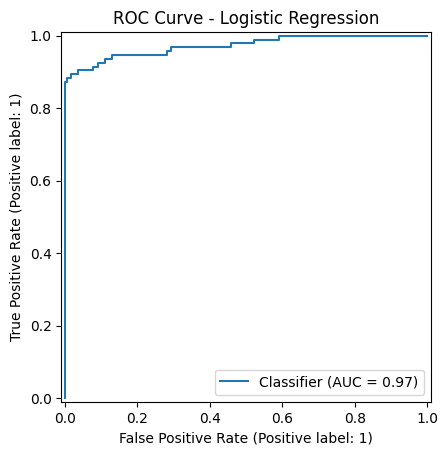

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Load data
df = pd.read_csv("creditcard.csv")

# Preprocess
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

df = df.drop(columns=["Amount", "Time"])

X = df.drop("Class", axis=1)
y = df["Class"]

# Drop rows with NaN values in y (Class column) from both X and y
# This is necessary because train_test_split with stratify=y cannot handle NaNs
na_mask = y.isna()
X = X[~na_mask]
y = y[~na_mask]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Metrics
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Detailed evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Logistic Regression")
plt.show()

#Logistic Regression Training

In [4]:
log_reg_weighted = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_weighted.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [5]:
y_pred_weighted = log_reg_weighted.predict(X_test)
y_prob_weighted = log_reg_weighted.predict_proba(X_test)[:, 1]

In [6]:
print("Precision:", precision_score(y_test, y_pred_weighted))
print("Recall:", recall_score(y_test, y_pred_weighted))
print("F1 Score:", f1_score(y_test, y_pred_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_weighted))

Precision: 0.06343283582089553
Recall: 0.9042553191489362
F1 Score: 0.11854951185495119
ROC-AUC: 0.9757068954113984


In [7]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))

Confusion Matrix:
[[50538  1255]
 [    9    85]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     51793
         1.0       0.06      0.90      0.12        94

    accuracy                           0.98     51887
   macro avg       0.53      0.94      0.55     51887
weighted avg       1.00      0.98      0.99     51887



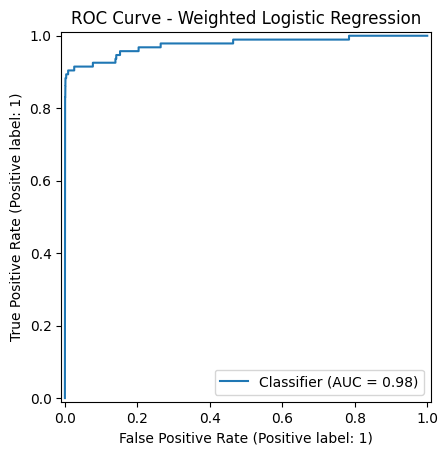

In [8]:
RocCurveDisplay.from_predictions(y_test, y_prob_weighted)
plt.title("ROC Curve - Weighted Logistic Regression")
plt.show()

#SMOTE

In [11]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape)
print("Original class distribution:")
print(y_train.value_counts())

print("\nResampled training set shape:", X_train_smote.shape)
print("Resampled class distribution:")
print(pd.Series(y_train_smote).value_counts())

Original training set shape: (207544, 29)
Original class distribution:
Class
0.0    207167
1.0       377
Name: count, dtype: int64

Resampled training set shape: (414334, 29)
Resampled class distribution:
Class
0.0    207167
1.0    207167
Name: count, dtype: int64


In [13]:
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_reg_smote.predict(X_test)
y_prob_smote = log_reg_smote.predict_proba(X_test)[:, 1]

print("SMOTE Logistic Regression Metrics")
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

SMOTE Logistic Regression Metrics
Precision: 0.05874316939890711
Recall: 0.9148936170212766
F1 Score: 0.110397946084724
ROC-AUC: 0.9715666415119764

Confusion Matrix:
[[50415  1378]
 [    8    86]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99     51793
         1.0       0.06      0.91      0.11        94

    accuracy                           0.97     51887
   macro avg       0.53      0.94      0.55     51887
weighted avg       1.00      0.97      0.98     51887



In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("SMOTE Random Forest Metrics")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

SMOTE Random Forest Metrics
Precision: 0.8863636363636364
Recall: 0.8297872340425532
F1 Score: 0.8571428571428571
ROC-AUC: 0.9719539237825205

Confusion Matrix:
[[51783    10]
 [   16    78]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51793
         1.0       0.89      0.83      0.86        94

    accuracy                           1.00     51887
   macro avg       0.94      0.91      0.93     51887
weighted avg       1.00      1.00      1.00     51887



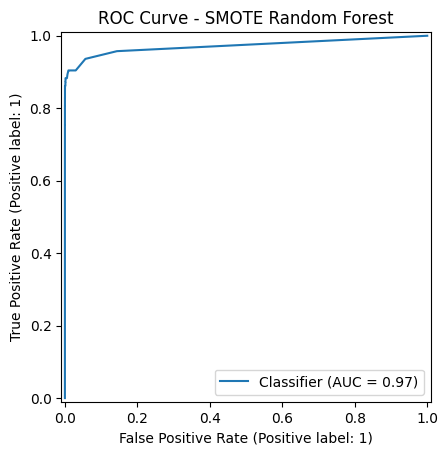

In [15]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - SMOTE Random Forest")
plt.show()

In [16]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "SMOTE Logistic Regression",
        "SMOTE Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_weighted),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

                          Model  Precision    Recall  F1 Score   ROC-AUC
0           Logistic Regression   0.847222  0.648936  0.734940  0.971975
1  Weighted Logistic Regression   0.063433  0.904255  0.118550  0.975707
2     SMOTE Logistic Regression   0.058743  0.914894  0.110398  0.971567
3           SMOTE Random Forest   0.886364  0.829787  0.857143  0.971954


In [17]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

V10    0.150580
V14    0.135384
V4     0.115667
V11    0.100749
V12    0.097790
V17    0.066351
V7     0.049766
V3     0.042294
V16    0.041813
V2     0.021216
dtype: float64


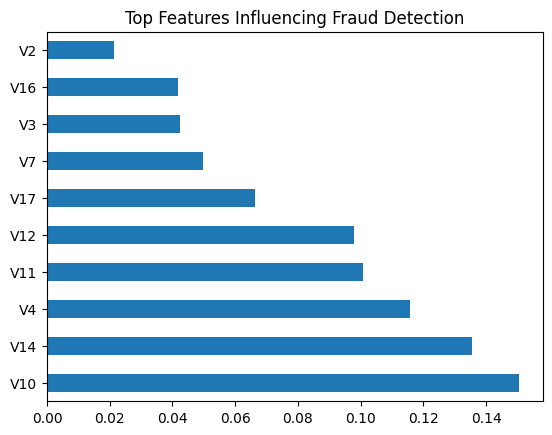

In [18]:
feature_importance.head(10).plot(kind="barh")
plt.title("Top Features Influencing Fraud Detection")
plt.show()

#XGBoost

In [20]:
!pip install xgboost
from xgboost import XGBClassifier

In [21]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [23]:
print("XGBoost Metrics")
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Metrics
Precision: 0.41624365482233505
Recall: 0.8723404255319149
F1 Score: 0.563573883161512
ROC-AUC: 0.9750625546621555

Confusion Matrix:
[[51678   115]
 [   12    82]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     51793
         1.0       0.42      0.87      0.56        94

    accuracy                           1.00     51887
   macro avg       0.71      0.94      0.78     51887
weighted avg       1.00      1.00      1.00     51887



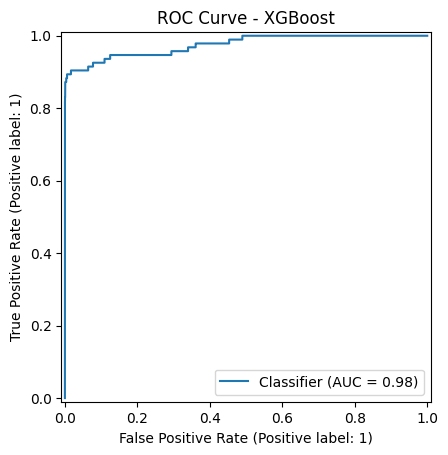

In [24]:
RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "SMOTE Logistic Regression",
        "SMOTE Random Forest",
        "XGBoost"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_weighted),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)

                          Model  Precision    Recall  F1 Score   ROC-AUC
0           Logistic Regression   0.847222  0.648936  0.734940  0.971975
1  Weighted Logistic Regression   0.063433  0.904255  0.118550  0.975707
2     SMOTE Logistic Regression   0.058743  0.914894  0.110398  0.971567
3           SMOTE Random Forest   0.886364  0.829787  0.857143  0.971954
4                       XGBoost   0.416244  0.872340  0.563574  0.975063
